In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np
import os

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [9]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
print("done")

done


In [10]:
dataset = datasets.ImageFolder("/kaggle/input/datasets/jhanvisonii/training-dataset/training_dataset", transform=transform)
print("done")

done


In [12]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print("done")

done


In [13]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
print("done")


done


In [14]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128*16*16, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self,x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)
print("Done")

Done


In [15]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout(0.3)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128*16*16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self,x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)
print("Done")

Done


In [16]:
resnet = models.resnet50(pretrained=True)

resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

resnet.fc = nn.Linear(resnet.fc.in_features, 2)

resnet = resnet.to(device)

print("Done")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s] 


Done


In [20]:
def train_model(model, name, epochs=10):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    model.to(device)

    best_acc = 0

    for epoch in range(epochs):

        model.train()
        correct, total = 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # validation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        print(f"{name} Epoch {epoch+1}: Train {train_acc:.4f} Val {val_acc:.4f}")

        # SAVE BEST MODEL
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{name}.pth")

    print(f"{name} BEST ACCURACY: {best_acc:.4f}")

print("done")
    

done


In [21]:
print(dataset.class_to_idx)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [17]:
cnn = BasicCNN()
train_model(cnn, "basic_cnn", epochs=12)

improved = ImprovedCNN()
train_model(improved, "improved_cnn", epochs=15)

train_model(resnet, "resnet50", epochs=10)

print("done")

basic_cnn Epoch 1: Train 0.8389 Val 0.8796
basic_cnn Epoch 2: Train 0.8990 Val 0.9235
basic_cnn Epoch 3: Train 0.9091 Val 0.9171
basic_cnn Epoch 4: Train 0.9164 Val 0.9320
basic_cnn Epoch 5: Train 0.9247 Val 0.9278
basic_cnn Epoch 6: Train 0.9314 Val 0.9263
basic_cnn Epoch 7: Train 0.9348 Val 0.9228
basic_cnn Epoch 8: Train 0.9426 Val 0.9348
basic_cnn Epoch 9: Train 0.9447 Val 0.9391
basic_cnn Epoch 10: Train 0.9536 Val 0.9320
basic_cnn Epoch 11: Train 0.9561 Val 0.9419
basic_cnn Epoch 12: Train 0.9637 Val 0.9462
basic_cnn BEST ACCURACY: 0.9462
improved_cnn Epoch 1: Train 0.8554 Val 0.9228
improved_cnn Epoch 2: Train 0.9095 Val 0.8952
improved_cnn Epoch 3: Train 0.9210 Val 0.9171
improved_cnn Epoch 4: Train 0.9297 Val 0.9200
improved_cnn Epoch 5: Train 0.9364 Val 0.9327
improved_cnn Epoch 6: Train 0.9341 Val 0.9455
improved_cnn Epoch 7: Train 0.9484 Val 0.9441
improved_cnn Epoch 8: Train 0.9516 Val 0.9455
improved_cnn Epoch 9: Train 0.9499 Val 0.9405
improved_cnn Epoch 10: Train 0.9582

In [22]:
save_path = "/kaggle/working/final_models"

torch.save(cnn.state_dict(), save_path + "basic_cnn.pth")
torch.save(improved.state_dict(), save_path + "improved_cnn.pth")
torch.save(resnet.state_dict(), save_path + "resnet50.pth")
print("Done")

Done


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cpu")

In [22]:
# BASIC CNN
model1 = BasicCNN()
model1.load_state_dict(torch.load("/kaggle/input/datasets/jhanvisonii/trained-models/CNN models/basic_cnn.pth", map_location=device))
model1.eval()

# IMPROVED CNN
model2 = ImprovedCNN()
model2.load_state_dict(torch.load("/kaggle/input/datasets/jhanvisonii/trained-models/CNN models/improved_cnn.pth", map_location=device))
model2.eval()

# RESNET50
model3 = models.resnet50(pretrained=False)
model3.conv1 = nn.Conv2d(1,64,7,2,3,bias=False)
model3.fc = nn.Linear(model3.fc.in_features, 2)

model3.load_state_dict(torch.load("/kaggle/input/datasets/jhanvisonii/trained-models/CNN models/resnet50.pth", map_location=device))
model3.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [63]:
from PIL import Image

class_names = ["NORMAL", "PNEUMONIA"]

img_path = "/kaggle/input/datasets/jhanvisonii/training-dataset/training_dataset/PNEUMONIA/sec_raw_40.png"  # change this

image = Image.open(img_path)
input_img = transform(image).unsqueeze(0)

with torch.no_grad():
    output = model3(input_img)
    _, pred = torch.max(output, 1)

print("Predicted:", class_names[pred.item()])

Predicted: PNEUMONIA


In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(model, loader):
    
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, cm, all_labels, all_preds



In [49]:
acc1, cm1, y1, p1 = evaluate_model(model1, val_loader)
acc2, cm2, y2, p2 = evaluate_model(model2, val_loader)
acc3, cm3, y3, p3 = evaluate_model(model3, val_loader)

print("Basic CNN Accuracy:", acc1)
print("Improved CNN Accuracy:", acc2)
print("ResNet50 Accuracy:", acc3)

Basic CNN Accuracy: 0.9461756373937678
Improved CNN Accuracy: 0.9752124645892352
ResNet50 Accuracy: 0.9865439093484419


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define everything again (SAFE)
model_names = ["Basic CNN", "Improved CNN", "ResNet50"]

accuracies = [acc1, acc2, acc3]   # uses your evaluated results
cms = [cm1, cm2, cm3]

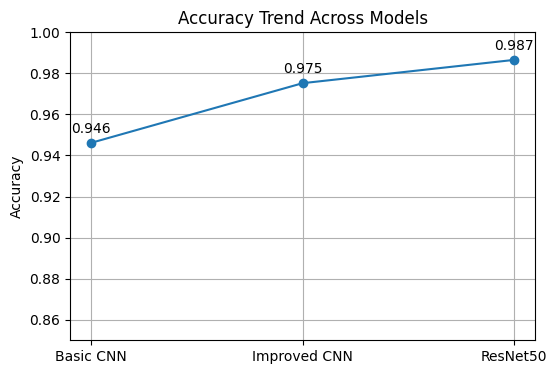

In [41]:
plt.figure(figsize=(6,4))

plt.plot(model_names, accuracies, marker='o')

for i, val in enumerate(accuracies):
    plt.text(i, val + 0.005, f"{val:.3f}", ha='center')

plt.title("Accuracy Trend Across Models")
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.0)

plt.grid()

plt.show()

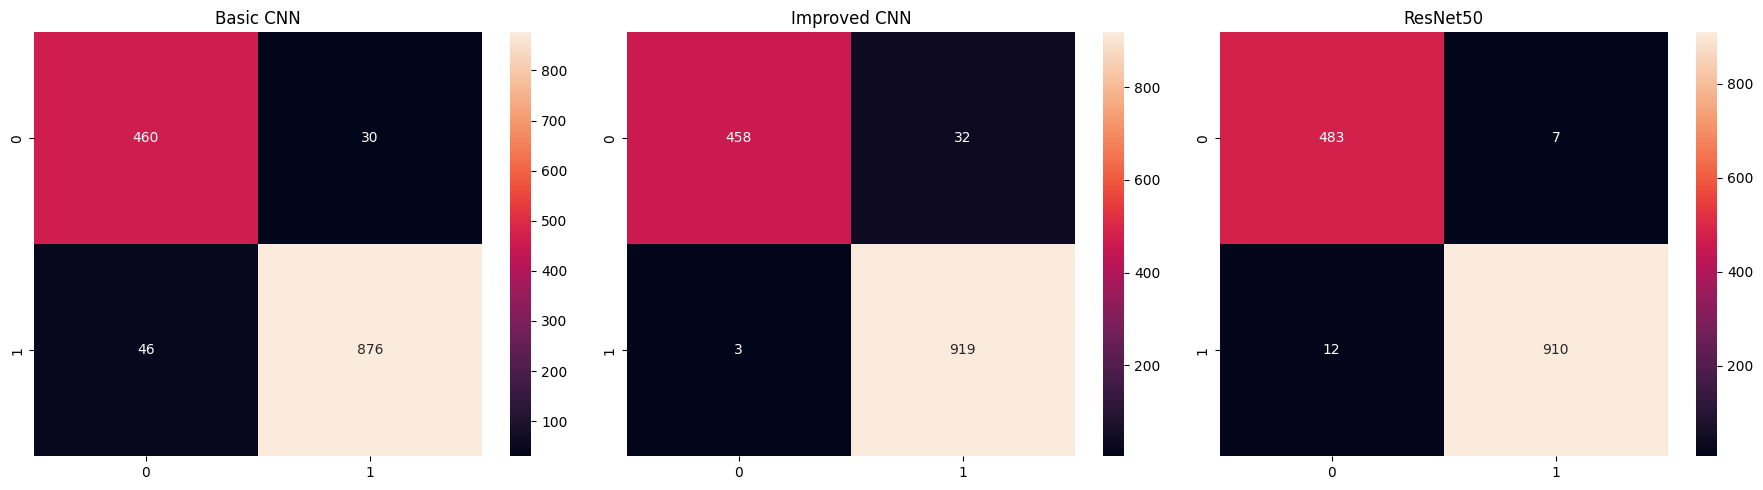

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.heatmap(cm1, annot=True, fmt="d", ax=axes[0])
axes[0].set_title("Basic CNN")

sns.heatmap(cm2, annot=True, fmt="d", ax=axes[1])
axes[1].set_title("Improved CNN")

sns.heatmap(cm3, annot=True, fmt="d", ax=axes[2])
axes[2].set_title("ResNet50")

plt.tight_layout()
plt.show()

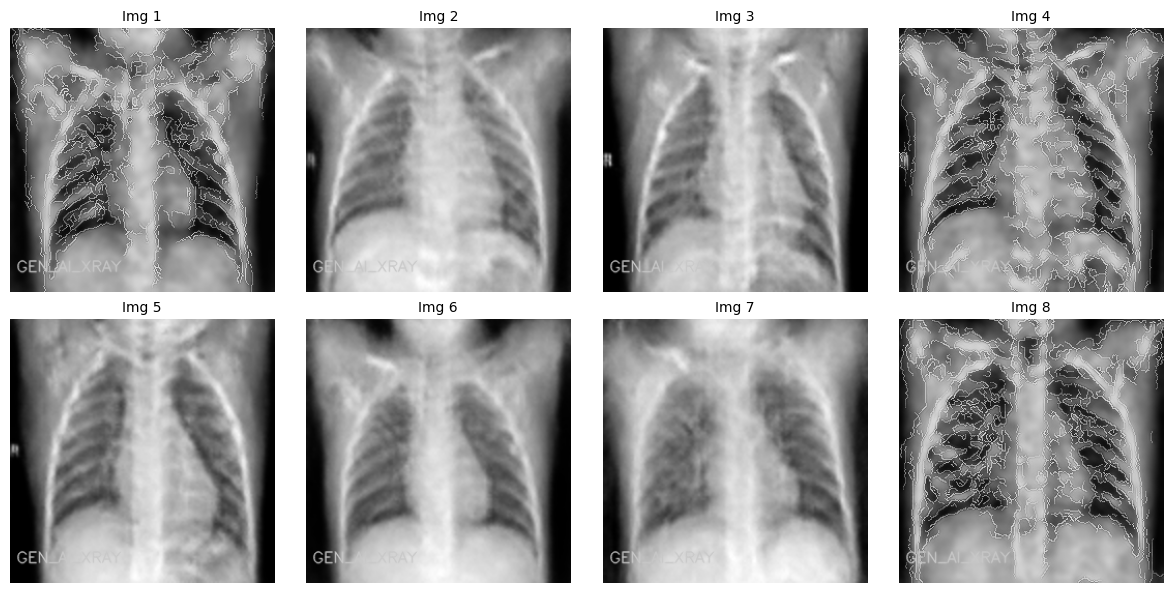

In [1]:
import matplotlib.pyplot as plt
from PIL import Image

# 🔹 PUT YOUR SELECTED IMAGE PATHS HERE
image_paths = [
    "/kaggle/input/datasets/jhanvisonii/training-dataset/training_dataset/NORMAL/sec_enhanced_187.png",
    "/kaggle/input/datasets/jhanvisonii/training-dataset/training_dataset/NORMAL/sec_raw_20.png",
    "/kaggle/input/datasets/jhanvisonii/training-dataset/training_dataset/NORMAL/sec_raw_89.png",
    "/kaggle/input/datasets/jhanvisonii/training-dataset/training_dataset/NORMAL/sec_enhanced_20.png",
    "/kaggle/input/datasets/jhanvisonii/training-dataset/training_dataset/PNEUMONIA/sec_raw_40.png",
    "/kaggle/input/datasets/jhanvisonii/training-dataset/training_dataset/PNEUMONIA/sec_raw_187.png",
    "/kaggle/input/datasets/jhanvisonii/training-dataset/training_dataset/PNEUMONIA/sec_raw_80.png",
    "/kaggle/input/datasets/jhanvisonii/training-dataset/training_dataset/PNEUMONIA/sec_enhanced_155.png"
]

# 🔹 GRID SIZE (2 rows × 4 columns = 8 images)
rows = 2
cols = 4

plt.figure(figsize=(12,6))

for i, path in enumerate(image_paths):
    img = Image.open(path)

    plt.subplot(rows, cols, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Img {i+1}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()